<a href="https://colab.research.google.com/github/s006aj/Planetary_defence_system/blob/main/final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORTING LIBRARIES, UPLOADING DATASET

In [13]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("nearest-earth-objects(1910-2024).csv")
print("Successfully loaded!")
print("Rows:", df.shape[0], "| Columns:", df.shape[1])
df.head()


Successfully loaded!
Rows: 338199 | Columns: 9


,neo_id,name,absolute_magnitude,estimated_diameter_min,estimated_diameter_max,orbiting_body,relative_velocity,miss_distance,is_hazardous
0,2162117,162117 (1998 SD15),19.14,0.394962,0.883161,Earth,71745.401048,5.814362e+07,False
1,2349507,349507 (2008 QY),18.50,0.530341,1.185878,Earth,109949.757148,5.580105e+07,True
2,2455415,455415 (2003 GA),21.45,0.136319,0.304818,Earth,24865.506798,6.720689e+07,False
3,3132126,(2002 PB),20.63,0.198863,0.444672,Earth,78890.076805,3.039644e+07,False
4,3557844,(2011 DW),22.70,0.076658,0.171412,Earth,56036.519484,6.311863e+07,False


DATA PREPROCESSING

In [14]:
print("Shape:", df.shape)
df.info()
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
columns_to_remove = ["id", "name", "neo_reference_id"]
for col in columns_to_remove:
    if col in df.columns:
        df = df.drop(columns=[col])

df = df.drop_duplicates()

df = df.fillna(df.median(numeric_only=True))

if "is_hazardous" in df.columns:
    df["is_hazardous"] = df["is_hazardous"].astype(int)

print("Cleaned shape:", df.shape)
print("Remaining missing values:", df.isnull().sum().sum())
df.head()

Shape: (338199, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338199 entries, 0 to 338198
Data columns (total 9 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   neo_id                  338199 non-null  int64  
 1   name                    338199 non-null  object 
 2   absolute_magnitude      338171 non-null  float64
 3   estimated_diameter_min  338171 non-null  float64
 4   estimated_diameter_max  338171 non-null  float64
 5   orbiting_body           338199 non-null  object 
 6   relative_velocity       338199 non-null  float64
 7   miss_distance           338199 non-null  float64
 8   is_hazardous            338199 non-null  bool   
dtypes: bool(1), float64(5), int64(1), object(2)
memory usage: 21.0+ MB
neo_id                     0
name                       0
absolute_magnitude        28
estimated_diameter_min    28
estimated_diameter_max    28
orbiting_body              0
relative_velocity          0
mi

,neo_id,absolute_magnitude,estimated_diameter_min,estimated_diameter_max,orbiting_body,relative_velocity,miss_distance,is_hazardous
0,2162117,19.14,0.394962,0.883161,Earth,71745.401048,5.814362e+07,0
1,2349507,18.50,0.530341,1.185878,Earth,109949.757148,5.580105e+07,1
2,2455415,21.45,0.136319,0.304818,Earth,24865.506798,6.720689e+07,0
3,3132126,20.63,0.198863,0.444672,Earth,78890.076805,3.039644e+07,0
4,3557844,22.70,0.076658,0.171412,Earth,56036.519484,6.311863e+07,0


EDA

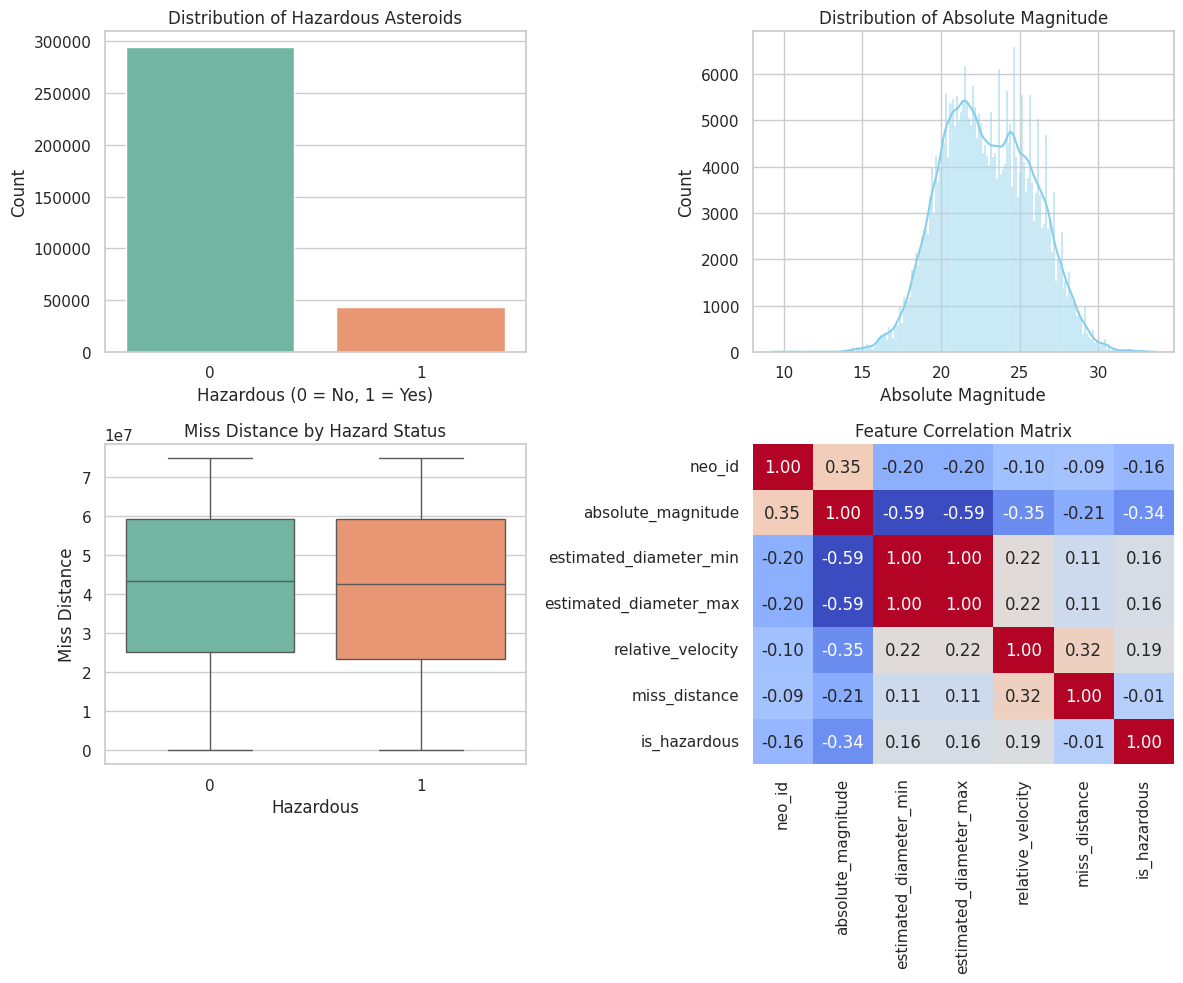

In [15]:

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)

sns.countplot(x="is_hazardous", data=df, palette="Set2", hue="is_hazardous", legend=False)
plt.title("Distribution of Hazardous Asteroids")
plt.xlabel("Hazardous (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.subplot(2, 2, 2)

sns.histplot(df["absolute_magnitude"], kde=True, color="skyblue")
plt.title("Distribution of Absolute Magnitude")
plt.xlabel("Absolute Magnitude")

plt.subplot(2, 2, 3)

sns.boxplot(x="is_hazardous", y="miss_distance", data=df, palette="Set2", hue="is_hazardous", legend=False)
plt.title("Miss Distance by Hazard Status")
plt.xlabel("Hazardous")
plt.ylabel("Miss Distance")

plt.subplot(2, 2, 4)
corr = df.select_dtypes(include=["number"]).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=False)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

finding outliers

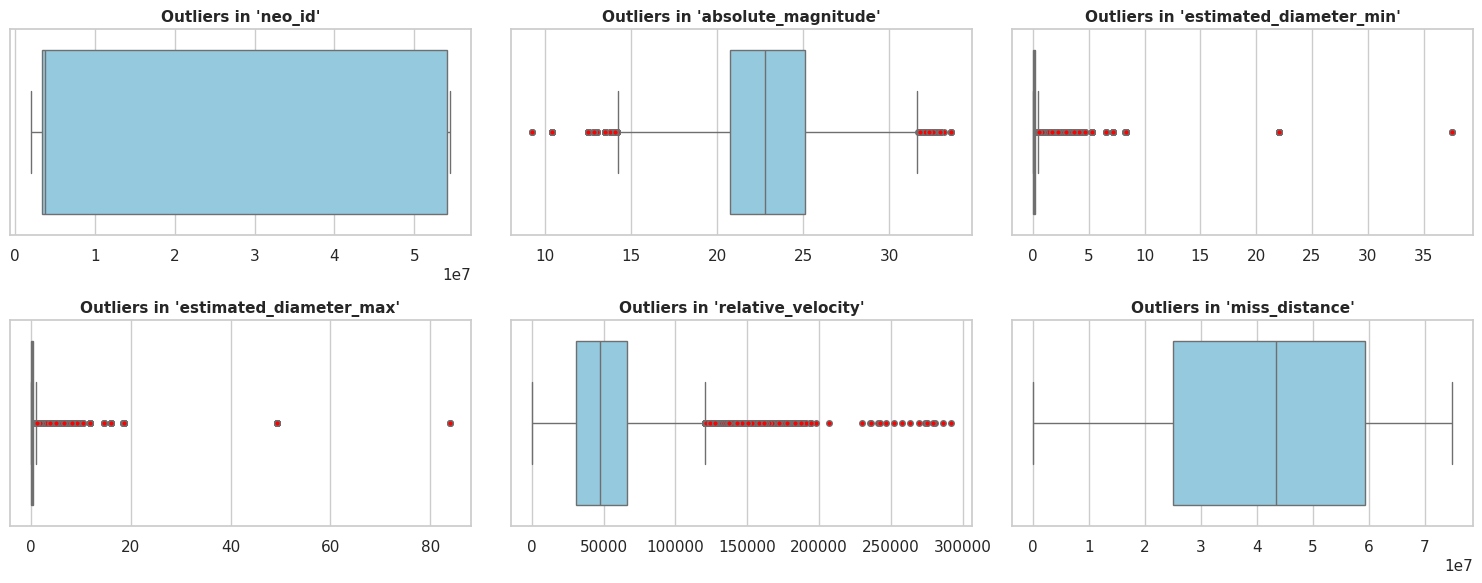

In [16]:
target_col = "is_hazardous"
num_cols = df.select_dtypes(include=["number"]).columns
num_cols = [c for c in num_cols if c != target_col]

num_features = len(num_cols)
plt.figure(figsize=(15, 3 * ((num_features + 2) // 3)))

for i, col in enumerate(num_cols, 1):
    plt.subplot((num_features + 2) // 3, 3, i)
    sns.boxplot(x=df[col], color="skyblue", flierprops={"markerfacecolor": "red", "markersize": 4})
    plt.title(f"Outliers in '{col}'", fontsize=11, fontweight="bold")
    plt.xlabel("")

plt.tight_layout()
plt.show()

/tmp/ipykernel_3152/1056314854.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="is_hazardous", y=col, data=df, palette="Set2")
/tmp/ipykernel_3152/1056314854.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="is_hazardous", y=col, data=df, palette="Set2")
/tmp/ipykernel_3152/1056314854.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="is_hazardous", y=col, data=df, palette="Set2")
/tmp/ipykernel_3152/1056314854.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. As

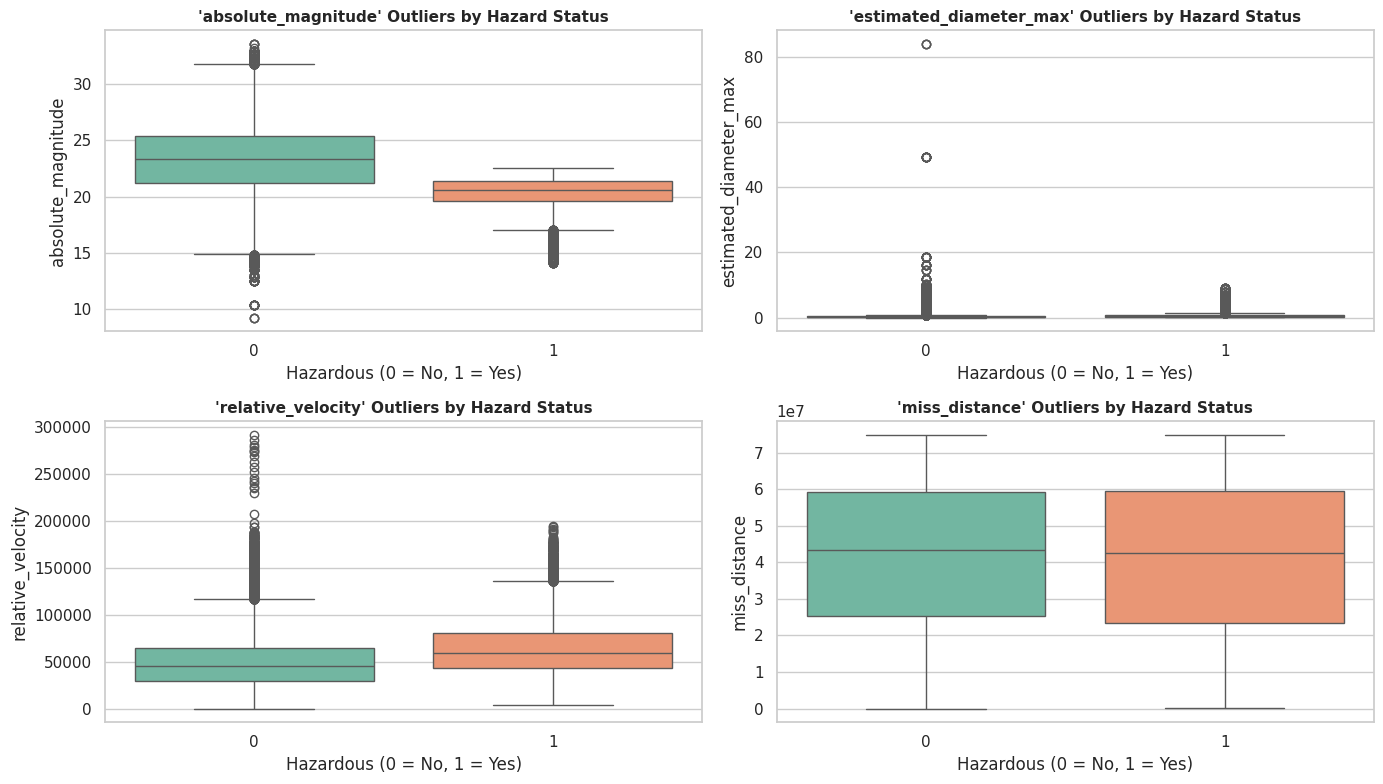

In [17]:
key_features = [
    col for col in ["absolute_magnitude", "estimated_diameter_max", "relative_velocity", "miss_distance"]
    if col in df.columns
]

if not key_features:
    key_features = num_cols[:4]

plt.figure(figsize=(14, 8))

for i, col in enumerate(key_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x="is_hazardous", y=col, data=df, palette="Set2")
    plt.title(f"'{col}' Outliers by Hazard Status", fontsize=11, fontweight="bold")
    plt.xlabel("Hazardous (0 = No, 1 = Yes)")

plt.tight_layout()
plt.show()